<a href="https://colab.research.google.com/github/carn51/Assignment-1/blob/main/2026_DSLab2_a3(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DS Lab2 - Assignment 3: Making a Discovery in the AirBnB Dataset**

This is the final assessment for DSLab2, giving you chance to bring together the full skillset you have acquired over the course of the module. Note that this assignment makes up the final 40% of the grade for the module. \\

Please make sure you use the software versions specified in this notebook, rather than the latest or other versions.

**Task**

**Visit the Inside AirBnB website and choose at least 3 locations in Australia that you would be interested in comparing.** \\

(Note - if you have problems in Chrome try downloading in Safari or some other browser) \\

You may employ any of the tools we have encountered so far in the module. Choose or switch interchangably between Pandas, PySpark, Dask, and PyTorch, as well as all the usual Python packages (e.g. numpy, matplotlib), and string manipulation tools if required. \\

A greater degree of independence is expected in choosing the correct tools for a particular task in this assignment, and your analysis should be thorough and well documented. Marks will be assigned for the quality of your code, including clarity, commenting and appropriate visualisations e.g. histograms, scatterplots etc. \\

**To Submit:**

1.   **This notebook containing your code and visualizations**
      - Please name the file "YOUR_NAME_DSLab226_a3.ipynb" (i.e. update "YOUR NAME" to be your name...)
      - The file *must* be in .ipynb format - markers will check that your code runs successfully.

2.  **All data files that are needed to run your code**
      - e.g. If you work on the detailed reviews from Sydney, **you must submit the csv file** of Sydney's detailed reviews with your code and report so we can run the code.

3.   **1-page report summarising your work and findings**
      - Please name the file "YOUR_NAME_DSLab226_a3_report.pdf" (i.e. update "YOUR NAME" to be your name...)
      - The file *must* be submitted in PDF format - LaTEX is recommended to generate your report, but you will not be penalised for a well-presented Word document exported as a PDF.
      - Please aim to provide your full report within 2 sides of A4 (marks will be lost for reports less than 1 side of A4 or for reports greater than 2 sides of A4.)



# Setup

In [ ]:
## Generic setup that we have used every week - this time they need to set up themselves
## Mount your Google Drive so we can access the data
from google.colab import drive
drive.mount('/content/drive',  force_remount=True)

Mounted at /content/drive


In [ ]:
## Import useful python modules
import pandas as pd ## to read in and explore data
import numpy as np ## Useful for calculations
import matplotlib.pyplot as plt ## Useful for plotting
import matplotlib.gridspec as gridspec ## Useful for plotting

# Q1 - Classification Problem
**25 marks for developing appropriate code for the chosen problem**

**25 marks for a report documenting your choice of problem, motivation, rationale for the developed solution, results and conclusions**

Design and implement a classification problem that can be applied to each of your locations. You may focus on any problem that interests you, but make sure to include the following elements:


*   Clean the input dataframes by doing the following:

> Remove NaNs in your columns of interest \\
> Update the Dtype of any columns if necessary \\

*   Choose a suitable classification algorithm
*   Visualise the output of your classifications using at least one appropriate plot
*   Apply your technique to at least two different locations
*   Describe the problem, the approach you have chosen, and the results in your accompanying report
*   Remember to comment your code to help the markers (and yourself!). Think about using functions wherever appropriate to make it easier to apply your code to multiple locations for example. \\

\\

**If you require inspiration, perhaps consider one of the following problems**

(no marks gained or lost for using a suggested problem vs an original problem):

1.   By treating "`review_score_rating`" as a discrete variable (i.e. a series of distinct bins) construct a model to predict which of your chosen categories a given listing will fall into, e.g. excellent, good, intermediate, poor, rubbish or similar. \\

2.   Use sentiment analysis to classify reviews (i.e. "`comments`" column) into positive, neutral, or negative sentiment categories. Compare the overall satisfaction level with AirBnB listings across different cities (probably best to use at least 3 locations).  \\


Feel free to develop either of these ideas or one of your own, and see where the analysis takes you. You may find it helpful to start by mapping out in comments the broad-brush steps of your analysis, then think about how to accomplish each stage. \\

\\



# Load Data

In [5]:
## Load first chosen dataset into a Pandas (or PySpark/Dask) DataFrame

data = pd.read_csv('/content/listings.csv.gz')
df =pd.DataFrame(data)


In [6]:
## A couple of lines to orientate oneself wrt the data, columns and dtypes.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7280 entries, 0 to 7279
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            7280 non-null   int64  
 1   listing_url                                   7280 non-null   object 
 2   scrape_id                                     7280 non-null   int64  
 3   last_scraped                                  7280 non-null   object 
 4   source                                        7280 non-null   object 
 5   name                                          7280 non-null   object 
 6   description                                   7204 non-null   object 
 7   neighborhood_overview                         3240 non-null   object 
 8   picture_url                                   7280 non-null   object 
 9   host_id                                       7280 non-null   i

EDA

<Axes: >

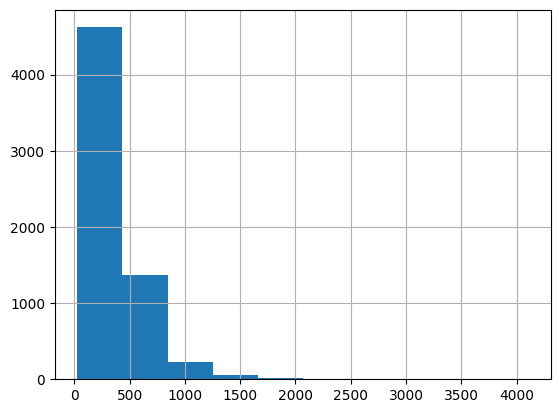

In [7]:
df['price'] = df['price'].str.replace('$', '').str.replace(',', '').astype('float')
#df['logprice'] = np.log(df['price'])
df['price'].hist()

# Clean Data

In [8]:
amenities_count = []

for row in df['amenities'] :
  amenities_count.append(len(str(row).split(',')))

df['amenities_count'] = amenities_count

In [9]:
import re

def clean_func(string):
  #ensure text is in fact strings
  text = str(string)
  #remove tags
  cleaner_text = re.sub('<[^<]+?>', '', text)
  full_clean_text = re.sub(r'[^a-zA-Z0-9\s]', '', cleaner_text)
  return full_clean_text

df['clean_descs'] = df['description'].apply(clean_func)

from textblob import TextBlob

sentiment = []
polarity = []

def sentiment_analysis(text_input):
  analysis = TextBlob(str(text_input))
  return analysis.sentiment.polarity

for row in df['clean_descs']:
  sentiment.append(sentiment_analysis(row))

df['sentiments'] = sentiment
df = df.drop(columns=['clean_descs'])
df.head(3)
#len(df)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,amenities_count,sentiments
0,21302,https://www.airbnb.com/rooms/21302,20250928035044,2025-09-28,city scrape,Great Ocean Haven,If you are looking for a beach house to relax ...,We are situated minutes walking distance to th...,https://a0.muscache.com/pictures/hosting/Hosti...,81292,...,4.63,NaN,f,3,2,1,0,0.40,43,0.537500
1,27561,https://www.airbnb.com/rooms/27561,20250928035044,2025-09-28,city scrape,Executive residence peaceful locale,A spacious retreat in a perfect location to re...,The area is generally quiet but seasonal touri...,https://a0.muscache.com/pictures/153948/809ee1...,119103,...,5.00,NaN,f,2,1,1,0,0.03,69,0.368519
2,70449,https://www.airbnb.com/rooms/70449,20250928035044,2025-09-28,city scrape,Otway foothills retreat,"Modern 2 bedroom house with 2 bathrooms, kitch...",NaN,https://a0.muscache.com/pictures/450690/937a7e...,357052,...,4.67,NaN,f,1,1,0,0,0.50,28,0.200000


In [10]:
from datetime import datetime

current = datetime.now()
df['host_since'] = pd.to_datetime(df['host_since'])
df['host_exp'] = ((current - df['host_since']) / pd.Timedelta(days= 365.25))

df['host_exp'].head(3)
df = df.drop(columns = ['host_since'])

Categorical Columns: label or onehot

In [11]:
df['room_type'].unique()

array(['Entire home/apt', 'Private room', 'Hotel room', 'Shared room'],
      dtype=object)

Pick columns

In [12]:
df1 = df[['reviews_per_month',  'sentiments' , 'bathrooms', 'review_scores_value', 'review_scores_rating', 'price', 'room_type', 'amenities_count', 'name']].dropna()

PySpark Investigate Outliers (specifics)

In [13]:
df1.to_csv('/content/listing_data_1', index=False)

In [14]:
!pip install pyspark
from pyspark.sql import SparkSession

spark = SparkSession.builder \
  .getOrCreate()

print(spark)

In [39]:
spark_df = spark.read.option("header",True)\
  .option("multiLine",True)\
  .csv("/content/listing_data_1")

spark_df.show(5)

spark_df.createOrReplaceTempView("listings2")

#finding outliers
spark.sql("SELECT sentiments, price, name AS top_priced FROM listings2 ORDER BY price").show(5)


+-----------------+------------------+---------+-------------------+--------------------+-----+---------------+---------------+--------------------+
|reviews_per_month|        sentiments|bathrooms|review_scores_value|review_scores_rating|price|      room_type|amenities_count|                name|
+-----------------+------------------+---------+-------------------+--------------------+-----+---------------+---------------+--------------------+
|              0.4|            0.5375|      3.5|               4.63|                4.91|814.0|Entire home/apt|             43|   Great Ocean Haven|
|             0.03|0.3685185185185185|      2.5|                5.0|                 5.0|363.0|Entire home/apt|             69|Executive residen...|
|              0.5|               0.2|      2.0|               4.67|                4.85|156.0|Entire home/apt|             28|Otway foothills r...|
|             1.22|            0.3235|      2.5|               4.72|                4.85|459.0|Entire home

# Classification

Initial descriptive stats

In [16]:
df1['price'].describe()

,price
count,5657.000000
mean,349.245537
std,244.594299
min,28.000000
25%,198.000000
50%,288.000000
75%,430.000000
max,4105.000000


Outliers

{'whiskers': [<matplotlib.lines.Line2D at 0x79c5d2841700>,
 'caps': [<matplotlib.lines.Line2D at 0x79c5d2841d00>,
 'boxes': [<matplotlib.lines.Line2D at 0x79c5d2841490>],
 'medians': [<matplotlib.lines.Line2D at 0x79c5d2842360>],
 'fliers': [<matplotlib.lines.Line2D at 0x79c5d2842690>],
 'means': []}

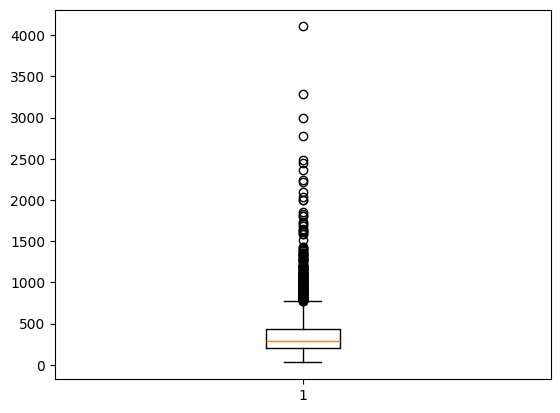

In [17]:
plt.boxplot(df1['price'])

In [18]:
#finding outliers amounts
q1 = np.percentile(df1['price'], 25)
q3 = np.percentile(df1['price'], 75)
iqr = q3 - q1
upper_lim = q3 + 1.5 * iqr
upper_pts_removed = df1[df1['price'] < upper_lim]
print(len(upper_pts_removed) / len(df1))

#no negative direction outliers

0.9482057627717871


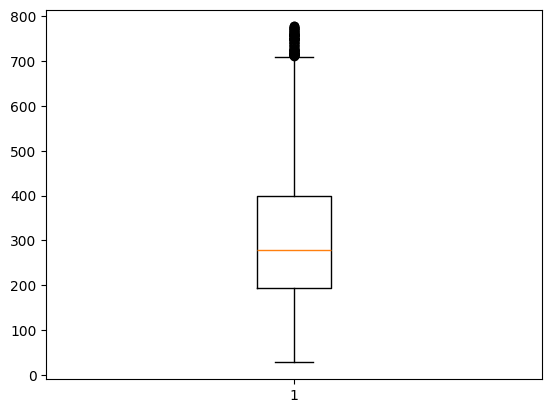

In [19]:
plt.boxplot(upper_pts_removed['price'])
plt.show()

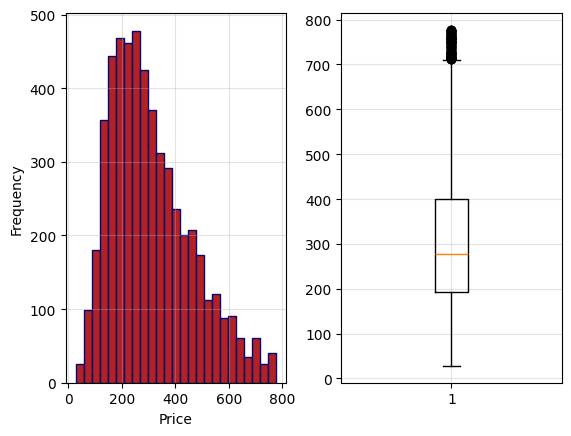

In [61]:
plt.subplot(1, 2, 1)
plt.ylabel('Frequency')
plt.xlabel('Price')
plt.grid(alpha=0.35)
plt.subplots_adjust(wspace = .25)
plt.hist(upper_pts_removed['price'], color= 'firebrick', edgecolor='navy', bins=25)

plt.subplot(1, 2, 2)
plt.boxplot(upper_pts_removed['price'])
plt.grid(alpha=0.35)
plt.show()

# If time log through whole analysis **remove before submission**

After outlier removal descriptive stats

In [20]:
upper_pts_removed['price'].describe()

,price
count,5364.000000
mean,309.387211
std,153.046560
min,28.000000
25%,193.000000
50%,278.000000
75%,400.000000
max,777.000000


PySpark, Potentially group property types/ remove every unusual, by popularity

In [21]:
upper_pts_removed.to_csv('/content/listing_data_2', index=False)

In [22]:
spark_df = spark.read.option("header",True)\
  .option("multiLine",True)\
  .csv("/content/listing_data_2")

spark_df.show(5)

+-----------------+-------------------+---------+-------------------+--------------------+-----+---------------+---------------+--------------------+
|reviews_per_month|         sentiments|bathrooms|review_scores_value|review_scores_rating|price|      room_type|amenities_count|                name|
+-----------------+-------------------+---------+-------------------+--------------------+-----+---------------+---------------+--------------------+
|             0.03| 0.3685185185185185|      2.5|                5.0|                 5.0|363.0|Entire home/apt|             69|Executive residen...|
|              0.5|                0.2|      2.0|               4.67|                4.85|156.0|Entire home/apt|             28|Otway foothills r...|
|             1.22|             0.3235|      2.5|               4.72|                4.85|459.0|Entire home/apt|             50|Sea-Lit - luxury ...|
|             0.23|                0.0|      2.0|               4.74|                4.85|600.0|Enti

In [23]:
spark_df.printSchema()
spark_df.createOrReplaceTempView("listings")

#change price to numerical


#can  now use spark sql
spark.sql('SELECT room_type, AVG(price) AS room_group_means FROM listings GROUP BY room_type').show()

root
 |-- reviews_per_month: string (nullable = true)
 |-- sentiments: string (nullable = true)
 |-- bathrooms: string (nullable = true)
 |-- review_scores_value: string (nullable = true)
 |-- review_scores_rating: string (nullable = true)
 |-- price: string (nullable = true)
 |-- room_type: string (nullable = true)
 |-- amenities_count: string (nullable = true)
 |-- name: string (nullable = true)

+---------------+------------------+
|      room_type|  room_group_means|
+---------------+------------------+
|    Shared room|              49.0|
|     Hotel room|209.42857142857142|
|Entire home/apt| 322.0489042207792|
|   Private room|165.39523809523808|
+---------------+------------------+



Split, back to Pandas (PySpark for investigation), doesn't need transfer of data

In [28]:
from sklearn.model_selection import train_test_split

X = upper_pts_removed.drop(columns = ['price', 'name'])
y = np.log(upper_pts_removed['price'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

Label Encode according to group means

In [29]:
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer

label_enc = LabelEncoder()

#dictating order
mapping = {'Shared room': 0,
           'Private room': 1,
           'Hotel room': 2,
           'Entire home/apt': 3}
df['room_type'] = df['room_type'].map(mapping)

X_train['room_type'] = label_enc.fit_transform(X_train['room_type'])
X_test['room_type'] = label_enc.transform(X_test['room_type'])



In [63]:
## Write your code here

from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(max_depth = 10,
                               n_estimators = 300,
                               max_features=5,
                               n_jobs = -1,
                               oob_score=True)
rf_reg.fit(X_train, y_train)

y_preds = rf_reg.predict(X_test)

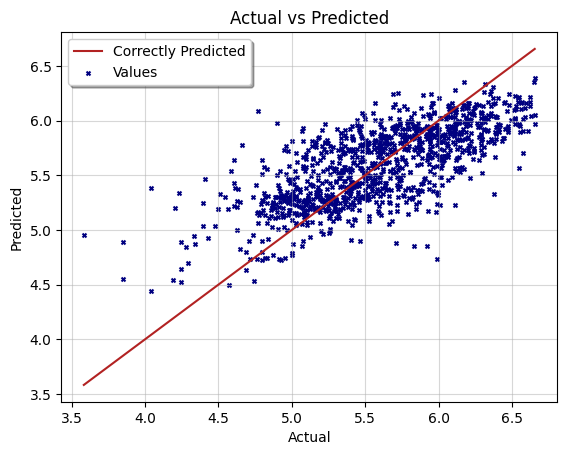

In [31]:
## Add as many boxes as you like
plt.title('Actual vs Predicted')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='firebrick', label= 'Correctly Predicted')
plt.scatter(y_test, y_preds, marker= 'x', s=8, color = 'navy', label = 'Values')
plt.legend(shadow = True)
plt.plot()
plt.show()

Observing correlations

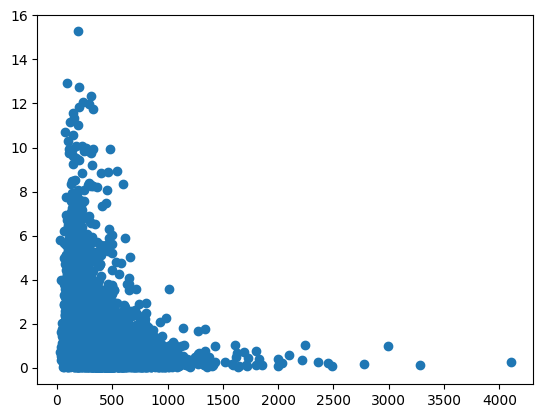

In [32]:
plt.scatter(df1['price'], df1['reviews_per_month'])
plt.show()

Review Scores Correlation

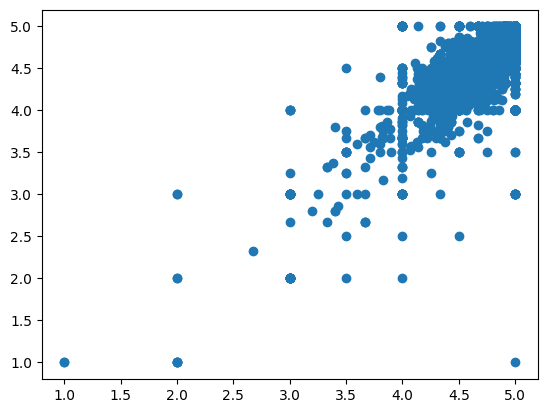

In [33]:
plt.scatter(df['review_scores_rating'], df['review_scores_value'])
plt.show()

In [64]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_preds)
print(mse)
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_preds)
print("R² Score:", r2)

oob_error = oob_error = 1 - rf_reg.oob_score_

print(oob_error)

list(zip(rf_reg.feature_names_in_, rf_reg.feature_importances_))

0.13062717198436608
R² Score: 0.5112817128469771
0.5144015262138376


[('reviews_per_month', np.float64(0.19542917220231448)),
 ('sentiments', np.float64(0.08003727820910567)),
 ('bathrooms', np.float64(0.33872244482695874)),
 ('review_scores_value', np.float64(0.07464407512818076)),
 ('review_scores_rating', np.float64(0.07503014578512897)),
 ('room_type', np.float64(0.14710531032336138)),
 ('amenities_count', np.float64(0.08903157352495004))]

In [35]:
r2 = .49
n = len(y_test)
k = X.shape[1]

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)
adj_r2

0.4866478873239436

#Q2 - Regression Problem

**25 marks for developing appropriate code for the chosen problem**

**25 marks for a report documenting your choice of problem, motivation, rationale for the developed solution, results and conclusions** \\

Design and implement a regression problem that can be applied to each of your locations (and potentially to a merged set of locations). You may focus on any problem that interests you, but make sure to include the following elements:


*   Clean the input dataframes by doing the following:

> Remove NaNs in your columns of interest \\
> Update the Dtype of any columns if necessary \\

*   Choose a suitable regression algorithm
*   Decide whether to include categorical data or not, and deal with it appropriately
*   Visualise the output of your algorithm using at least one appropriate plot per location
*   Apply your technique to at least two different locations
*   Evaluate the results
*   Describe the problem, the approach you have chosen, and the results in your accompanying report
*   Remember to comment your code to help the markers (and yourself!). Think about using functions wherever appropriate to make it easier to apply your code to multiple locations for example. \\

\\

**If you require inspiration, perhaps consider the following**

(no marks gained or lost for using a suggested problem vs an original problem):

* Either of the problems suggested in section one could be treated as a
regression problem. For instance, the average `review_score_rating` or `average sentiment` are esssentially continuous variables. If you used your own problem instead you might also consider whether it is possible to adapt it into a regression problem. \\


You may find it helpful to start by mapping out in comments the broad-brush steps of your analysis, then think about how to accomplish each stage. For certain tasks it may be appropriate to utilise the GPUs available through Google colab. To avoid being thrown off, perhaps develop your code using the CPU first, and speed things up when you have a working setup to explore your idea and the results. \\

\\



# Load Data

In [ ]:
## Load first chosen dataset into a Pandas (or PySpark/Dask) DataFrame



# Clean Data

In [ ]:
## Do any appropriate cleaning here


# Regression Problem

In [ ]:
## Write your code here


In [ ]:
## Add as many boxes as you like